In [3]:
import pandas as pd
df = pd.read_csv("/content/data_k_mean.txt", sep = ' ', names  = ['x', 'y'])
df

,x,y
0,-7.87157,-4.86573
1,-4.76661,-6.87944
2,-6.67986,-5.83080
3,-8.93021,-4.15571
4,-7.91375,-4.22840
...,...,...
2995,-8.06037,-4.84080
2996,7.47328,0.37321
2997,6.91832,-0.32132
2998,-8.23828,-4.00405


In [4]:
k = 2

In [6]:
c1  = df.iloc[500].values
c2  = df.iloc[200].values
c1, c2

(array([-9.11147, -5.0321 ]), array([5.67849, 2.28385]))

In [15]:
while (True):
  df['distance_from_c1'] = (df['x'] - c1[0])**2 + (df['y'] - c1[1])**2
  df['distance_from_c2'] = (df['x'] - c2[0])**2 + (df['y'] - c2[1])**2
  df['group'] = df[['distance_from_c1', 'distance_from_c2']].apply(lambda x: 1 if x[0]<x[1] else 2, axis = 1)
  new_c1 =  df[df['group'] == 1][['x', 'y']].mean().values
  new_c2 =  df[df['group'] == 2][['x', 'y']].mean().values
  print(new_c1, new_c2)
  print(c1, c2)
  if (c1 == new_c1).all() and (c2 == new_c2).all():
    break
  c1 = new_c1
  c2 = new_c2

[-6.81708974 -5.72084663] [7.21831715 0.78213112]
[-6.81708974 -5.72084663] [7.21831715 0.78213112]


<ipython-input-15-045708dd48b7>:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df['group'] = df[['distance_from_c1', 'distance_from_c2']].apply(lambda x: 1 if x[0]<x[1] else 2, axis = 1)


In [16]:
df

,x,y,distance_from_c1,distance_from_c2,group
0,-7.87157,-4.86573,1.843153,259.603029,1
1,-4.76661,-6.87944,5.546806,202.338151,1
2,-6.67986,-5.83080,0.030922,236.890186,1
3,-8.93021,-4.15571,6.914930,285.157204,1
4,-7.91375,-4.22840,3.430061,254.084878,1
...,...,...,...,...,...
2995,-8.06037,-4.84080,2.320228,265.055635,1
2996,7.47328,0.37321,241.352193,0.232223,2
2997,6.91832,-0.32132,217.816368,1.307603,2
2998,-8.23828,-4.00405,4.967172,261.813925,1


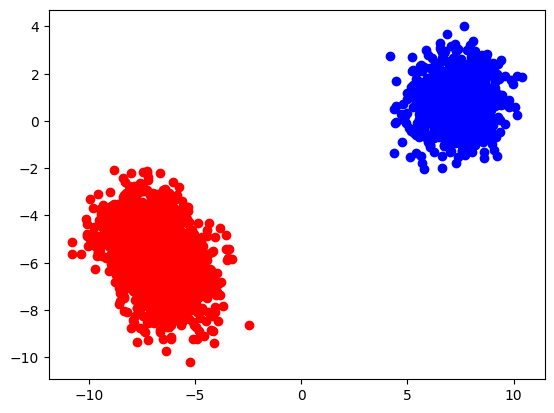

In [17]:
import matplotlib.pyplot as plt
plt.scatter(df[df['group']==1]['x'], df[df['group']==1]['y'], c = 'red')
plt.scatter(df[df['group']==2]['x'], df[df['group']==2]['y'], c = 'blue')